In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("odins0n/ucf-crime-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.0G/11.0G [01:51<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1


In [12]:
import os

path = "/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1"

for item in os.listdir(path):
    print(item)

Train
Test


In [2]:
import os
import random

# Dataset path
dataset_path = "/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train"

# Get all class folders
classes = sorted(os.listdir(dataset_path))

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # Randomly select 10 images
    sample_images = random.sample(images, min(5, len(images)))

    print(f"\n📂 Class: {cls}\n")

    for img in sample_images:
        print(img)


📂 Class: Abuse

Abuse017_x264_1060.png
Abuse048_x264_1380.png
Abuse042_x264_15420.png
Abuse042_x264_16970.png
Abuse043_x264_3720.png

📂 Class: Arrest

Arrest026_x264_5860.png
Arrest003_x264_1900.png
Arrest011_x264_1500.png
Arrest027_x264_350.png
Arrest049_x264_11110.png

📂 Class: Arson

Arson019_x264_94670.png
Arson030_x264_4050.png
Arson019_x264_77850.png
Arson013_x264_2500.png
Arson042_x264_2240.png

📂 Class: Assault

Assault017_x264_120.png
Assault008_x264_2810.png
Assault027_x264_3260.png
Assault008_x264_4730.png
Assault009_x264_80.png

📂 Class: Burglary

Burglary056_x264_500.png
Burglary062_x264_10260.png
Burglary095_x264_38520.png
Burglary075_x264_7350.png
Burglary064_x264_37760.png

📂 Class: Explosion

Explosion046_x264_96570.png
Explosion046_x264_75270.png
Explosion046_x264_83840.png
Explosion046_x264_26040.png
Explosion046_x264_139560.png

📂 Class: Fighting

Fighting037_x264_820.png
Fighting048_x264_2110.png
Fighting008_x264_1140.png
Fighting024_x264_1580.png
Fighting024_x264

In [3]:
# ================= IMPORT ===================
import os
import cv2
import numpy as np
import random
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
# ================= PATH ===================
DATASET_PATH = "/root/.cache/kagglehub/datasets/odins0n/ucf-crime-dataset/versions/1/Train"

In [5]:
import re

def parse_filename(filename):
    name = filename.replace(".png", "")

    parts = name.split("_")

    # video_id = everything except last numeric part
    # frame_id = last numeric value

    frame_id = None

    # reverse loop to find last number
    for part in reversed(parts):
        if part.isdigit():
            frame_id = int(part)
            break

    # fallback (if no digit found)
    if frame_id is None:
        raise ValueError(f"Frame ID not found in filename: {filename}")

    # video_id = everything before frame_id
    video_id_parts = []

    for part in parts:
        if part == str(frame_id):
            break
        video_id_parts.append(part)

    video_id = "_".join(video_id_parts)

    return video_id, frame_id

In [6]:
# ================= GROUPING ===================
video_dict = defaultdict(list)

classes = sorted(os.listdir(DATASET_PATH))

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(class_path):
        video_id, frame_id = parse_filename(img_name)

        full_path = os.path.join(class_path, img_name)

        video_dict[(cls, video_id)].append((frame_id, full_path))

In [7]:
for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(class_path)[:10]:
        print(img_name, "→", parse_filename(img_name))

Abuse036_x264_2800.png → ('Abuse036_x264', 2800)
Abuse042_x264_8180.png → ('Abuse042_x264', 8180)
Abuse003_x264_3310.png → ('Abuse003_x264', 3310)
Abuse008_x264_7000.png → ('Abuse008_x264', 7000)
Abuse021_x264_1510.png → ('Abuse021_x264', 1510)
Abuse005_x264_770.png → ('Abuse005_x264', 770)
Abuse015_x264_3950.png → ('Abuse015_x264', 3950)
Abuse014_x264_160.png → ('Abuse014_x264', 160)
Abuse004_x264_13090.png → ('Abuse004_x264', 13090)
Abuse043_x264_1980.png → ('Abuse043_x264', 1980)
Arrest021_x264_8670.png → ('Arrest021_x264', 8670)
Arrest049_x264_860.png → ('Arrest049_x264', 860)
Arrest051_x264_1560.png → ('Arrest051_x264', 1560)
Arrest016_x264_7570.png → ('Arrest016_x264', 7570)
Arrest047_x264_11870.png → ('Arrest047_x264', 11870)
Arrest033_x264_510.png → ('Arrest033_x264', 510)
Arrest029_x264_4640.png → ('Arrest029_x264', 4640)
Arrest026_x264_4150.png → ('Arrest026_x264', 4150)
Arrest016_x264_6500.png → ('Arrest016_x264', 6500)
Arrest008_x264_4000.png → ('Arrest008_x264', 4000)
Arso

In [8]:
# ================= SORT ===================
for key in video_dict:
    video_dict[key] = sorted(video_dict[key], key=lambda x: x[0])

In [9]:
# ================= FILTER ===================

def is_blurry(image, threshold=50):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return var < threshold


def has_motion(prev, curr, threshold=5):
    diff = cv2.absdiff(prev, curr)
    return np.mean(diff) > threshold


def filter_frames(frame_list):
    filtered = []
    prev_img = None

    for _, path in frame_list:
        img = cv2.imread(path)

        if img is None:
            continue

        if is_blurry(img):
            continue

        if prev_img is not None:
            if not has_motion(prev_img, img):
                continue

        filtered.append((_, path))
        prev_img = img

    return filtered

In [13]:
# ================= APPLY FILTER ===================
filtered_video_dict = {}

for key, frames in tqdm(video_dict.items()):
    filtered = filter_frames(frames)

    if len(filtered) >= 16:   # keep usable sequences only
        filtered_video_dict[key] = filtered

100%|██████████| 1610/1610 [11:30<00:00,  2.33it/s]


In [14]:
# ================= SEQUENCE CREATION ===================

SEQ_LEN = 16

sequences = []
labels = []

for (cls, vid), frames in filtered_video_dict.items():

    frame_paths = [f[1] for f in frames]

    for i in range(len(frame_paths) - SEQ_LEN + 1):
        seq = frame_paths[i:i+SEQ_LEN]

        sequences.append(seq)
        labels.append(cls)

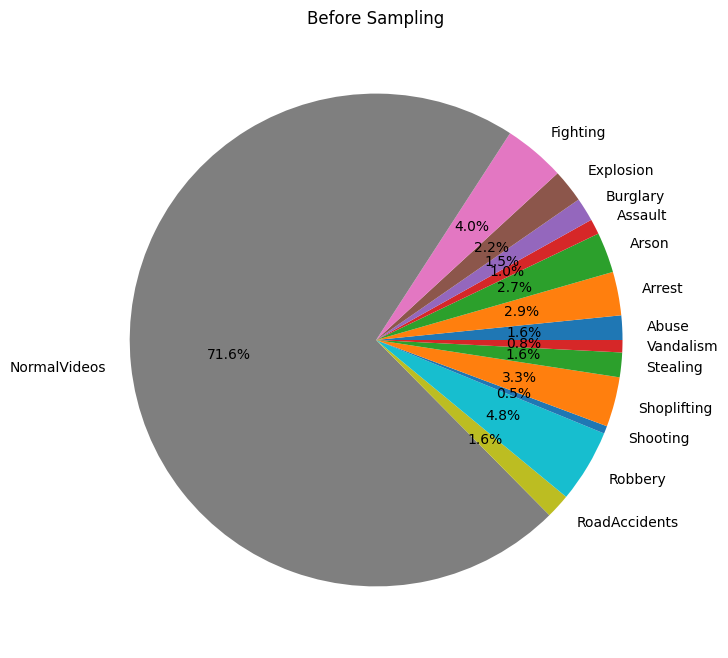

In [15]:
# ================= CLASS COUNT ===================
from collections import Counter

counter = Counter(labels)

plt.figure(figsize=(8,8))
plt.pie(counter.values(), labels=counter.keys(), autopct='%1.1f%%')
plt.title("Before Sampling")
plt.show()

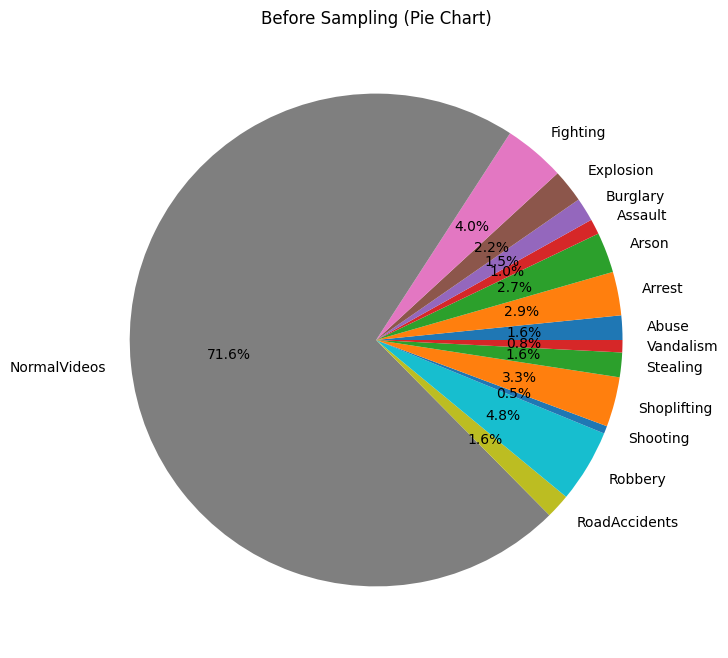

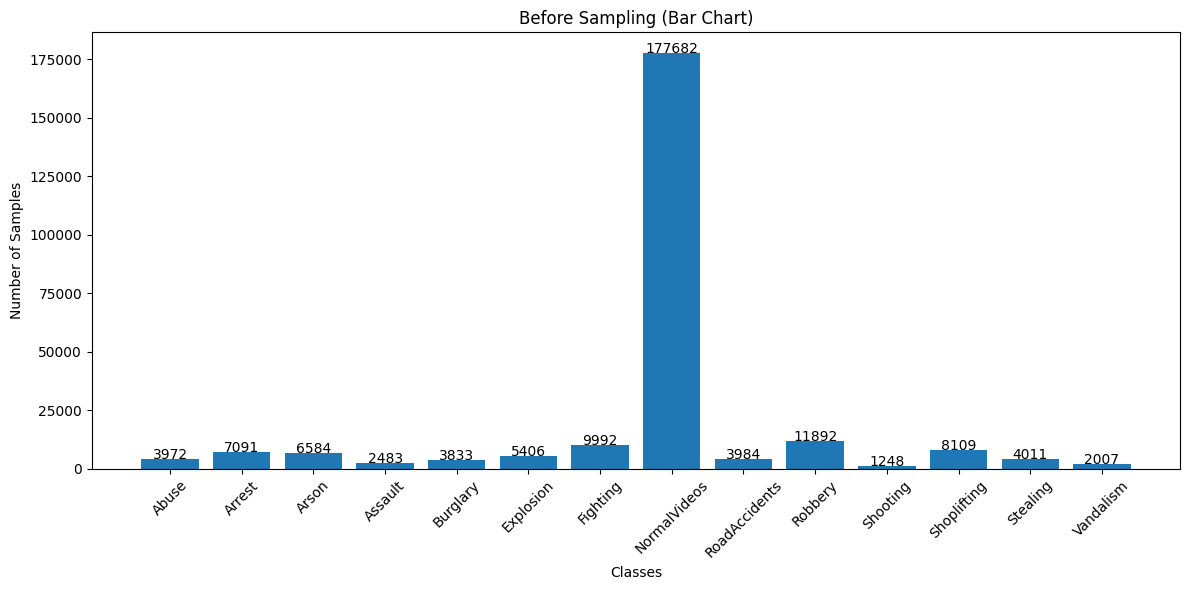

In [16]:
# ================= CLASS COUNT ===================
from collections import Counter

counter = Counter(labels)

# -------- PIE CHART --------
plt.figure(figsize=(8,8))
plt.pie(counter.values(), labels=counter.keys(), autopct='%1.1f%%')
plt.title("Before Sampling (Pie Chart)")
plt.show()


# -------- BAR CHART --------
plt.figure(figsize=(12,6))

classes = list(counter.keys())
counts = list(counter.values())

plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Before Sampling (Bar Chart)")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")

# value show on top of bar
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

In [17]:
# ================= UNDERSAMPLING ===================

from collections import defaultdict
import random

balanced_sequences = []
balanced_labels = []

class_data = defaultdict(list)

# group by class
for seq, lbl in zip(sequences, labels):
    class_data[lbl].append(seq)

# 🔥 find smallest class size
min_samples = min(len(seqs) for seqs in class_data.values())

print("Target (min class size):", min_samples)

# 🔥 undersample all classes to min_samples
for cls in class_data:
    seqs = class_data[cls]

    # randomly pick min_samples
    seqs = random.sample(seqs, min_samples)

    balanced_sequences.extend(seqs)
    balanced_labels.extend([cls] * min_samples)

Target (min class size): 1248


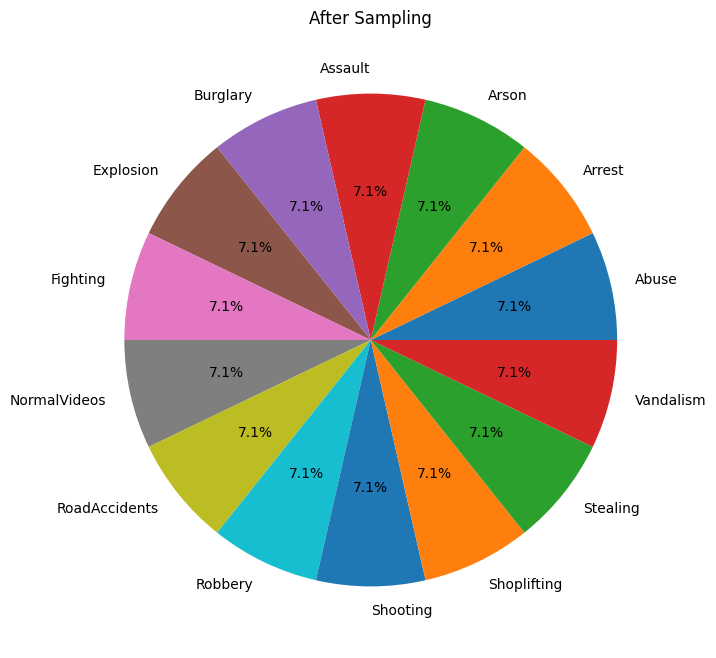

In [18]:
counter_after = Counter(balanced_labels)

plt.figure(figsize=(8,8))
plt.pie(counter_after.values(), labels=counter_after.keys(), autopct='%1.1f%%')
plt.title("After Sampling")
plt.show()

In [19]:
# ================= SPLIT ===================

train_seq, temp_seq, train_lbl, temp_lbl = train_test_split(
    balanced_sequences, balanced_labels, test_size=0.3, stratify=balanced_labels, random_state=42
)

val_seq, test_seq, val_lbl, test_lbl = train_test_split(
    temp_seq, temp_lbl, test_size=0.5, stratify=temp_lbl, random_state=42
)

print(len(train_seq), len(val_seq), len(test_seq))

12230 2621 2621


In [20]:

# ================= IMAGE LOADER ===================

IMG_SIZE = 128

def load_sequence(seq_paths):
    frames = []

    for path in seq_paths:
        img = cv2.imread(path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        frames.append(img)

    return np.array(frames)

In [21]:
# ================= AUGMENTATION ===================

def augment_sequence(seq):

    if random.random() < 0.5:
        seq = np.flip(seq, axis=2)  # horizontal flip

    if random.random() < 0.5:
        brightness = random.uniform(0.8, 1.2)
        seq = np.clip(seq * brightness, 0, 1)

    return seq

In [22]:
# ================= GENERATOR ===================

def data_generator(sequences, labels, batch_size=16):

    while True:
        idx = np.random.permutation(len(sequences))

        for i in range(0, len(sequences), batch_size):
            batch_idx = idx[i:i+batch_size]

            X, y = [], []

            for j in batch_idx:
                seq = load_sequence(sequences[j])
                seq = augment_sequence(seq)

                X.append(seq)
                y.append(labels[j])

            yield np.array(X), np.array(y)

In [23]:
# ================= LABEL ENCODING ===================

label_map = {label:i for i, label in enumerate(sorted(set(balanced_labels)))}

y_train = np.array([label_map[l] for l in train_lbl])
y_val   = np.array([label_map[l] for l in val_lbl])
y_test  = np.array([label_map[l] for l in test_lbl])

In [24]:
sample = load_sequence(train_seq[0])

print("Sequence Shape:", sample.shape)
# Expected: (10, 128, 128, 3)

Sequence Shape: (16, 128, 128, 3)


In [25]:
# ================= IMPORT ===================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [26]:
# ================= PARAMS ===================
SEQ_LEN = 16
IMG_SIZE = 128
NUM_CLASSES = len(label_map)
BATCH_SIZE = 8
EPOCHS = 20

In [27]:
# ================= ATTENTION ===================
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, x):
        e = tf.matmul(x, self.W) + self.b
        e = tf.nn.tanh(e)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

In [28]:
# ================= CNN BACKBONE ===================
def build_cnn():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False  # first freeze

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    return Model(base_model.input, x)

In [29]:
# ================= FULL MODEL ===================
def build_model():
    cnn = build_cnn()

    input_layer = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))

    x = TimeDistributed(cnn)(input_layer)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = AttentionLayer()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(input_layer, output)

    return model

In [ ]:
# ================= COMPILE ===================
model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 256)        │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 256)            │           272 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,735,774 (14.25 MB)

 Trainable params: 1,477,790 (5.64 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ================= GENERATOR ===================
def data_generator(sequences, labels, batch_size=16):

    while True:
        idx = np.random.permutation(len(sequences))

        for i in range(0, len(sequences), batch_size):
            batch_idx = idx[i:i+batch_size]

            X, y = [], []

            for j in batch_idx:
                seq = load_sequence(sequences[j])
                seq = augment_sequence(seq)

                X.append(seq)
                y.append(labels[j])

            yield np.array(X), np.array(y)

In [32]:
# ================= CALLBACKS ===================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=7,
    min_lr=1e-6
)

In [37]:
# ================= TRAIN ===================
train_gen = data_generator(train_seq, y_train, BATCH_SIZE)
val_gen   = data_generator(val_seq, y_val, BATCH_SIZE)
test_gen = data_generator(test_seq, y_test, BATCH_SIZE)

In [ ]:


history = model.fit(
    train_gen,
    steps_per_epoch=len(train_seq)//BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_seq)//BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 437s 242ms/step - accuracy: 0.6005 - loss: 1.3783 - val_accuracy: 0.8486 - val_loss: 0.6403 - learning_rate: 1.0000e-04
Epoch 2/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 327s 214ms/step - accuracy: 0.8613 - loss: 0.5326 - val_accuracy: 0.9109 - val_loss: 0.3408 - learning_rate: 1.0000e-04
Epoch 3/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 324s 212ms/step - accuracy: 0.9295 - loss: 0.2814 - val_accuracy: 0.9518 - val_loss: 0.1863 - learning_rate: 1.0000e-04
Epoch 4/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 321s 210ms/step - accuracy: 0.9590 - loss: 0.1664 - val_accuracy: 0.9663 - val_loss: 0.1327 - learning_rate: 1.0000e-04
Epoch 5/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 322s 211ms/step - accuracy: 0.9737 - loss: 0.1062 - val_accuracy: 0.9690 - val_loss: 0.1236 - learning_rate: 1.0000e-04
Epoch 6/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 382s 250ms/step - accuracy: 0.9812 - loss: 0.0760 - val_accuracy: 0.9713 - val_loss: 0.0979 - learning_rate: 1.0000e-04
Epoch 7/20
1528/1528 ━━━━━━━

In [ ]:
# ================= TEST (FIXED) ===================
from tqdm import tqdm

y_pred_classes = []
y_true = []

BATCH_SIZE = 8

for i in tqdm(range(0, len(test_seq), BATCH_SIZE)):

    batch_seq = test_seq[i:i+BATCH_SIZE]
    batch_lbl = y_test[i:i+BATCH_SIZE]

    X_batch = []

    for seq in batch_seq:
        frames = []
        for path in seq:
            img = cv2.imread(path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            frames.append(img)

        X_batch.append(frames)

    X_batch = np.array(X_batch)

    preds = model.predict(X_batch, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred_classes.extend(preds)
    y_true.extend(batch_lbl)

y_pred_classes = np.array(y_pred_classes)
y_true = np.array(y_true)

100%|██████████| 328/328 [02:13<00:00,  2.45it/s]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       187
           1       0.97      0.99      0.98       187
           2       0.98      0.99      0.99       187
           3       1.00      1.00      1.00       187
           4       0.98      0.98      0.98       188
           5       0.99      1.00      1.00       187
           6       0.98      0.98      0.98       188
           7       0.95      0.92      0.93       187
           8       0.98      0.98      0.98       187
           9       0.98      0.95      0.97       187
          10       1.00      1.00      1.00       188
          11       1.00      0.97      0.98       187
          12       0.98      0.99      0.99       187
          13       0.98      1.00      0.99       187

    accuracy                           0.98      2621
   macro avg       0.98      0.98      0.98      2621
weighted avg       0.98      0.98      0.98      2621



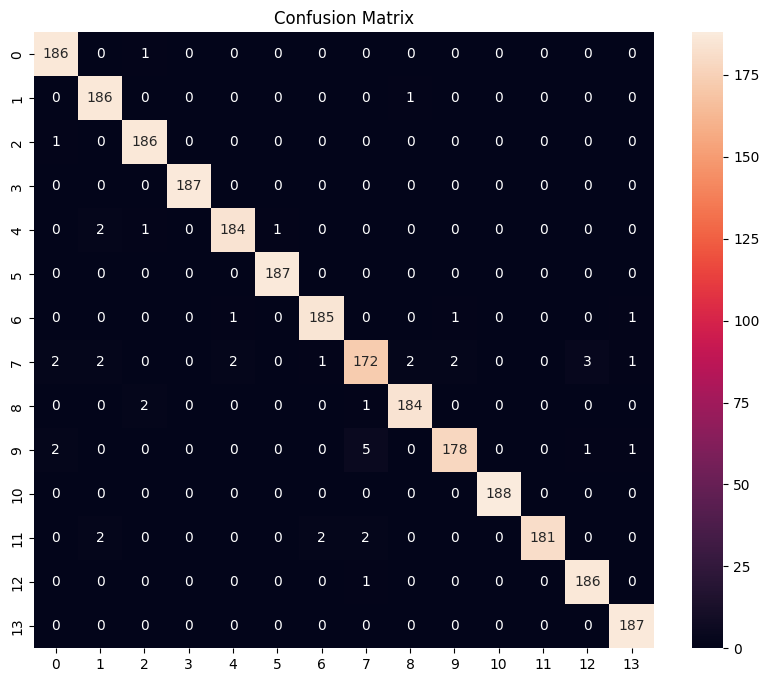

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

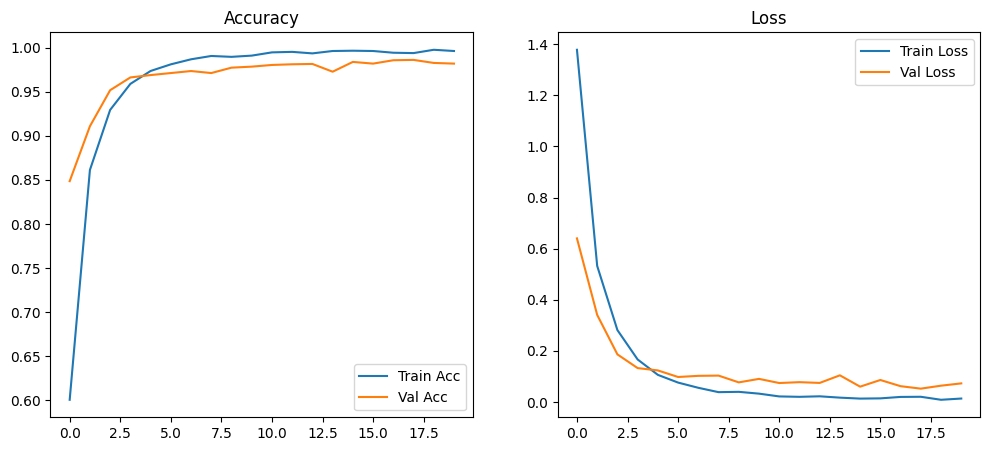

In [ ]:
# ================= CURVES ===================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
print("Train unique:", len(set(map(tuple, train_seq))))
print("Test unique:", len(set(map(tuple, test_seq))))

Train unique: 12230
Test unique: 2621


In [ ]:
train_set = set(map(tuple, train_seq))
test_set = set(map(tuple, test_seq))

overlap = train_set.intersection(test_set)

print("Overlap:", len(overlap))

Overlap: 0


In [ ]:
# ================= REPORT ===================
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       187
           1       0.97      0.99      0.98       187
           2       0.98      0.99      0.99       187
           3       1.00      1.00      1.00       187
           4       0.98      0.98      0.98       188
           5       0.99      1.00      1.00       187
           6       0.98      0.98      0.98       188
           7       0.95      0.92      0.93       187
           8       0.98      0.98      0.98       187
           9       0.98      0.95      0.97       187
          10       1.00      1.00      1.00       188
          11       1.00      0.97      0.98       187
          12       0.98      0.99      0.99       187
          13       0.98      1.00      0.99       187

    accuracy                           0.98      2621
   macro avg       0.98      0.98      0.98      2621
weighted avg       0.98      0.98      0.98      2621



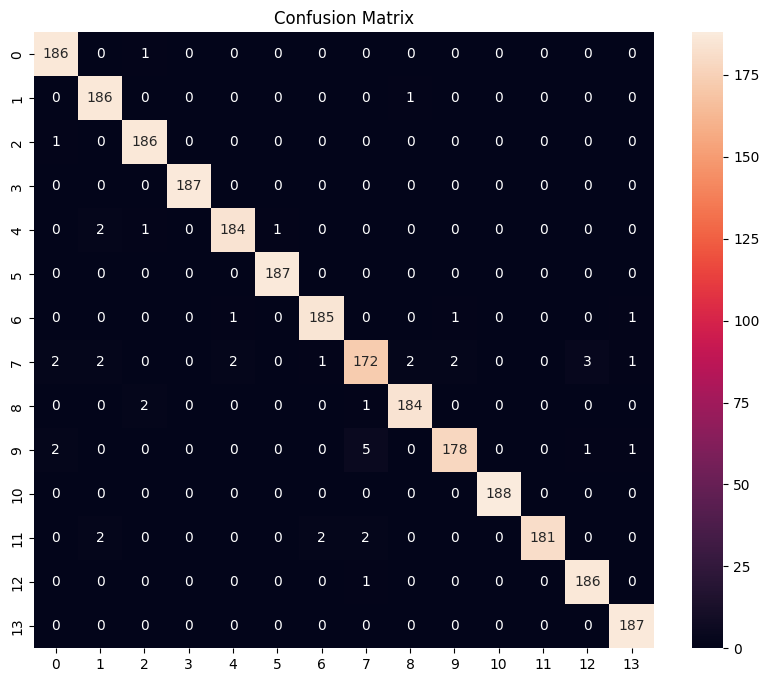

In [ ]:
# ================= CONFUSION MATRIX ===================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

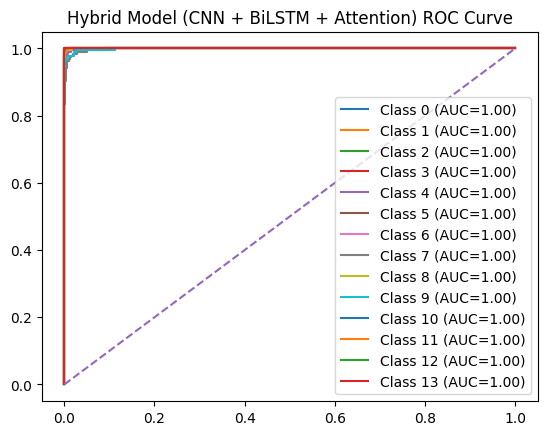

In [ ]:
plot_roc(model, "Hybrid Model (CNN + BiLSTM + Attention)")

In [30]:
# ================= CNN ONLY MODEL ===================

def build_cnn_only_model():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    input_layer = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))

    x = TimeDistributed(base_model)(input_layer)
    x = TimeDistributed(GlobalAveragePooling2D())(x)

    # 🔥 flatten sequence (no temporal learning)
    x = Flatten()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(input_layer, output)
    return model


cnn_model = build_cnn_only_model()

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,358 (18.62 MB)

 Trainable params: 2,623,374 (10.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
history_cnn = cnn_model.fit(
    train_gen,
    steps_per_epoch=len(train_seq)//BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_seq)//BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 470s 230ms/step - accuracy: 0.4876 - loss: 1.6042 - val_accuracy: 0.7515 - val_loss: 0.8804 - learning_rate: 1.0000e-04
Epoch 2/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 322s 179ms/step - accuracy: 0.6982 - loss: 0.9407 - val_accuracy: 0.8502 - val_loss: 0.5475 - learning_rate: 1.0000e-04
Epoch 3/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 274s 179ms/step - accuracy: 0.7751 - loss: 0.7034 - val_accuracy: 0.8804 - val_loss: 0.4327 - learning_rate: 1.0000e-04
Epoch 4/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 320s 210ms/step - accuracy: 0.8181 - loss: 0.5674 - val_accuracy: 0.9005 - val_loss: 0.3662 - learning_rate: 1.0000e-04
Epoch 5/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 276s 181ms/step - accuracy: 0.8449 - loss: 0.4724 - val_accuracy: 0.9159 - val_loss: 0.3088 - learning_rate: 1.0000e-04
Epoch 6/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 272s 178ms/step - accuracy: 0.8661 - loss: 0.4071 - val_accuracy: 0.9223 - val_loss: 0.2755 - learning_rate: 1.0000e-04
Epoch 7/20
1528/1528 ━━━━━━━

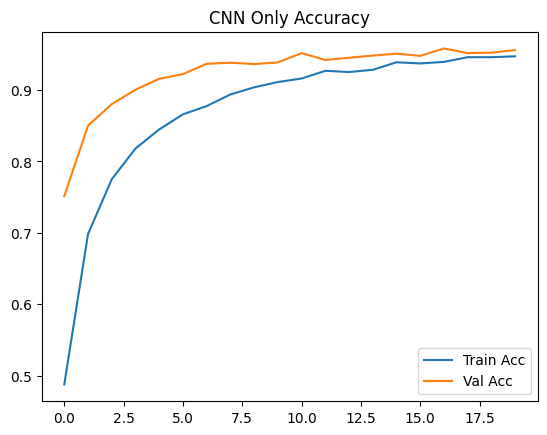

In [35]:
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('CNN Only Accuracy')
plt.legend()
plt.show()

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# ================= TEST EVALUATION =================
print("\n===== TEST EVALUATION =====")
test_loss, test_acc = cnn_model.evaluate(test_gen, steps=len(test_seq)//BATCH_SIZE)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


===== TEST EVALUATION =====
327/327 ━━━━━━━━━━━━━━━━━━━━ 63s 194ms/step - accuracy: 0.9621 - loss: 0.1450
Test Accuracy: 0.9621
Test Loss: 0.1450


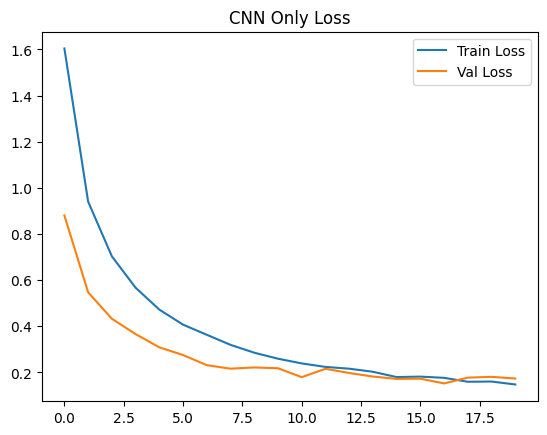

In [46]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Only Loss')
plt.legend()
plt.show()

In [52]:
steps = len(test_seq) // BATCH_SIZE
if len(test_seq) % BATCH_SIZE != 0:
    steps += 1

test_loss, test_acc = cnn_model.evaluate(test_gen, steps=steps)

print("Test Accuracy:", test_acc)

328/328 ━━━━━━━━━━━━━━━━━━━━ 71s 215ms/step - accuracy: 0.9634 - loss: 0.1424
Test Accuracy: 0.9633727669715881


In [53]:
y_pred = cnn_model.predict(test_gen, steps=steps)
y_pred_classes = np.argmax(y_pred, axis=1)

328/328 ━━━━━━━━━━━━━━━━━━━━ 211s 333ms/step


In [54]:
y_true = y_test[:len(y_pred_classes)]

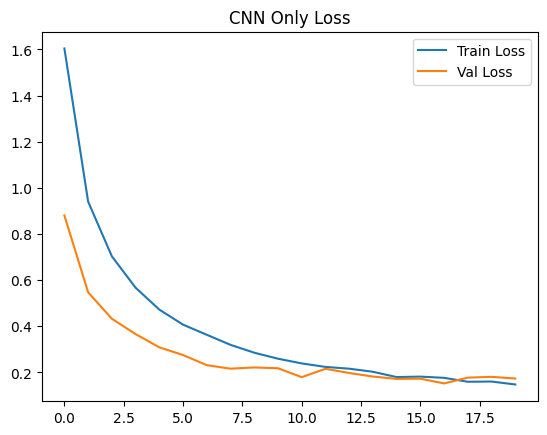

In [57]:
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Only Loss')
plt.legend()
plt.show()

BiLSTM Test Accuracy: 0.9625
BiLSTM Final Training Accuracy: 0.4084
BiLSTM Final Validation Accuracy: 0.4879

===== BiLSTM Classification Report =====
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       187
           1       0.95      0.92      0.93       187
           2       0.98      0.96      0.97       187
           3       0.99      0.98      0.99       187
           4       0.99      0.95      0.97       188
           5       0.99      0.97      0.98       187
           6       0.99      0.96      0.98       188
           7       0.87      0.88      0.88       187
           8       0.93      0.96      0.94       187
           9       0.86      0.94      0.90       187
          10       0.98      0.97      0.98       188
          11       0.96      1.00      0.98       187
          12       0.96      0.99      0.98       187
          13       0.97      0.98      0.98       187

    accuracy                         

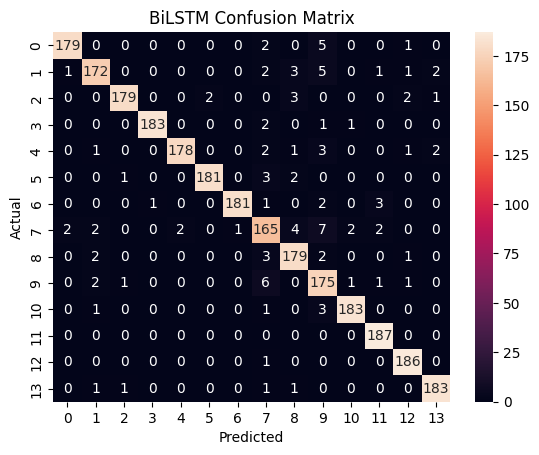

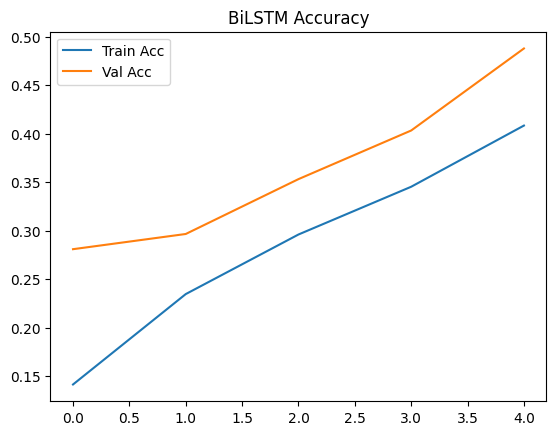

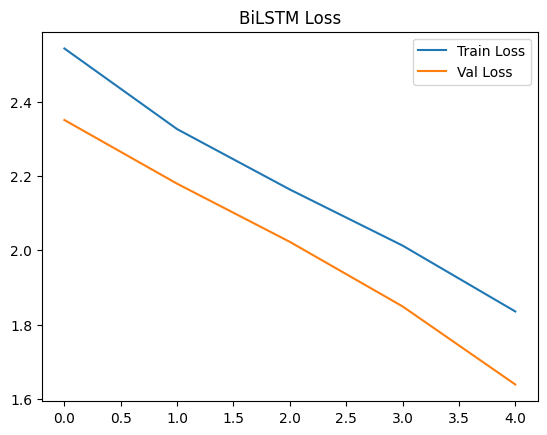

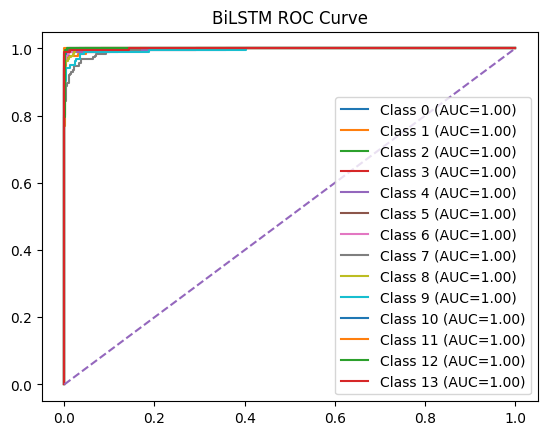

In [67]:
# ================= BiLSTM EVALUATION =================

# Generate predictions for the BiLSTM model on the test set
y_pred_classes_bilstm = []
y_true_labels_bilstm = []

# Re-initialize test_gen for predictions
test_gen_for_preds_bilstm = data_generator(test_seq, y_test, BATCH_SIZE)

num_test_samples = len(test_seq)
steps_for_prediction = (num_test_samples + BATCH_SIZE - 1) // BATCH_SIZE

for _ in range(steps_for_prediction):
    X_batch, y_batch = next(test_gen_for_preds_bilstm)
    preds = cnn_model.predict(X_batch, verbose=0)
    y_pred_classes_bilstm.extend(np.argmax(preds, axis=1))
    y_true_labels_bilstm.extend(y_batch)

y_pred_classes_bilstm = np.array(y_pred_classes_bilstm)
y_true_labels_bilstm = np.array(y_true_labels_bilstm)

# Calculate and print test accuracy
bilstm_test_loss, bilstm_test_acc = cnn_model.evaluate(test_gen, steps=len(test_seq)//BATCH_SIZE, verbose=0)
print(f"BiLSTM Test Accuracy: {bilstm_test_acc:.4f}")

# Print final training and validation accuracy from history
print(f"BiLSTM Final Training Accuracy: {history_bilstm.history['accuracy'][-1]:.4f}")
print(f"BiLSTM Final Validation Accuracy: {history_bilstm.history['val_accuracy'][-1]:.4f}")

# Evaluate and plot confusion matrix
evaluate_model(y_true_labels_bilstm, y_pred_classes_bilstm, "BiLSTM")

# Plot training and validation curves
plot_training(history_bilstm, "BiLSTM")

# Plot ROC curve
plot_roc(cnn_model, "BiLSTM")

CNN (MobileNetV2) Test Accuracy: 0.9644
CNN Final Training Accuracy: 0.9473
CNN Final Validation Accuracy: 0.9560

===== CNN (MobileNetV2) Classification Report =====
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       187
           1       0.96      0.93      0.95       187
           2       0.98      0.96      0.97       187
           3       0.99      0.98      0.99       187
           4       0.99      0.95      0.97       188
           5       0.99      0.98      0.99       187
           6       0.99      0.96      0.97       188
           7       0.90      0.91      0.91       187
           8       0.93      0.96      0.95       187
           9       0.88      0.94      0.91       187
          10       0.98      0.97      0.97       188
          11       0.98      1.00      0.99       187
          12       0.95      0.99      0.97       187
          13       0.97      0.98      0.98       187

    accuracy         

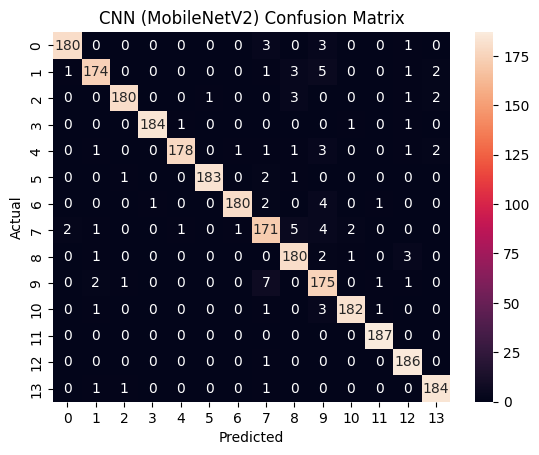

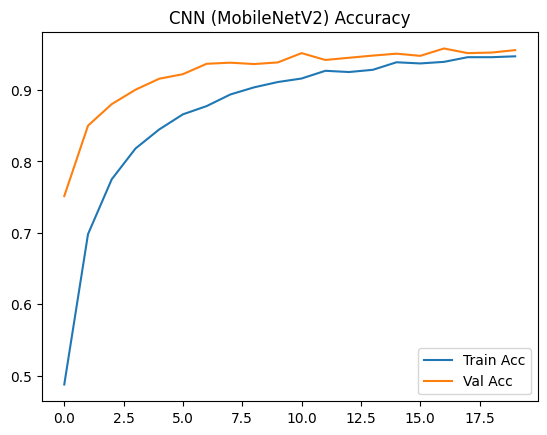

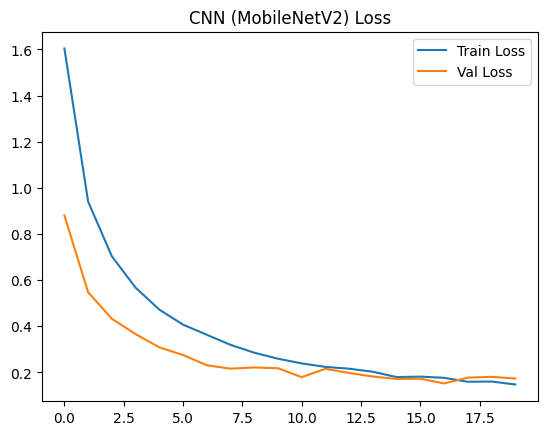

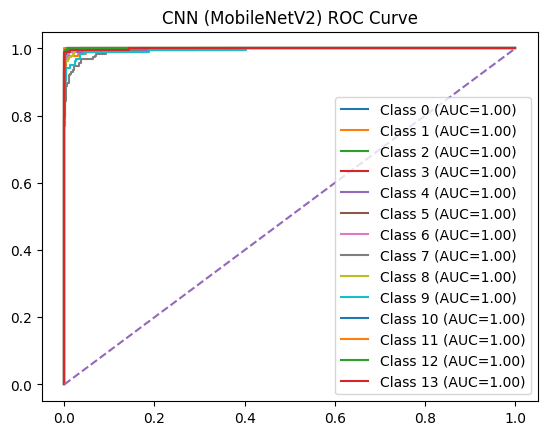

In [68]:
# ================= CNN (MobileNetV2) EVALUATION =================

from tensorflow.keras.applications import MobileNetV2
import numpy as np

# Generate predictions for the CNN model on the test set
y_pred_classes_cnn = []
y_true_labels_cnn = []

# Re-initialize test generator
test_gen_for_preds_cnn = data_generator(test_seq, y_test, BATCH_SIZE)

num_test_samples = len(test_seq)
steps_for_prediction = (num_test_samples + BATCH_SIZE - 1) // BATCH_SIZE

for _ in range(steps_for_prediction):
    X_batch, y_batch = next(test_gen_for_preds_cnn)

    preds = cnn_model.predict(X_batch, verbose=0)

    y_pred_classes_cnn.extend(np.argmax(preds, axis=1))
    y_true_labels_cnn.extend(y_batch)

y_pred_classes_cnn = np.array(y_pred_classes_cnn)
y_true_labels_cnn = np.array(y_true_labels_cnn)

# ================= TEST ACCURACY =================
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    test_gen,
    steps=len(test_seq)//BATCH_SIZE,
    verbose=0
)

print(f"CNN (MobileNetV2) Test Accuracy: {cnn_test_acc:.4f}")

# ================= TRAIN / VAL ACCURACY =================
print(f"CNN Final Training Accuracy: {history_cnn.history['accuracy'][-1]:.4f}")
print(f"CNN Final Validation Accuracy: {history_cnn.history['val_accuracy'][-1]:.4f}")

# ================= EVALUATION =================
evaluate_model(y_true_labels_cnn, y_pred_classes_cnn, "CNN (MobileNetV2)")

# ================= CURVES =================
plot_training(history_cnn, "CNN (MobileNetV2)")

# ================= ROC =================
plot_roc(cnn_model, "CNN (MobileNetV2)")

In [58]:
# ================= ONLY BiLSTM MODEL ===================

def build_bilstm_only_model():

    input_layer = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))

    # 🔥 each frame flatten
    x = TimeDistributed(Flatten())(input_layer)

    # 🔥 normalize feature scale (optional but good)
    x = TimeDistributed(Dense(256, activation='relu'))(x)

    # 🔥 sequence learning
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(input_layer, output)
    return model


bilstm_model = build_bilstm_only_model()

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 49152)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 256)        │    12,583,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,012,110 (49.64 MB)

 Trainable params: 13,012,110 (49.64 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history_bilstm = bilstm_model.fit(
    train_gen,
    steps_per_epoch=len(train_seq)//BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_seq)//BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 438s 281ms/step - accuracy: 0.1414 - loss: 2.5427 - val_accuracy: 0.2810 - val_loss: 2.3504 - learning_rate: 1.0000e-04
Epoch 2/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 444s 291ms/step - accuracy: 0.2347 - loss: 2.3259 - val_accuracy: 0.2966 - val_loss: 2.1791 - learning_rate: 1.0000e-04
Epoch 3/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 434s 284ms/step - accuracy: 0.2961 - loss: 2.1635 - val_accuracy: 0.3532 - val_loss: 2.0227 - learning_rate: 1.0000e-04
Epoch 4/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 445s 291ms/step - accuracy: 0.3454 - loss: 2.0127 - val_accuracy: 0.4034 - val_loss: 1.8491 - learning_rate: 1.0000e-04
Epoch 5/20
1528/1528 ━━━━━━━━━━━━━━━━━━━━ 446s 292ms/step - accuracy: 0.4084 - loss: 1.8355 - val_accuracy: 0.4879 - val_loss: 1.6392 - learning_rate: 1.0000e-04


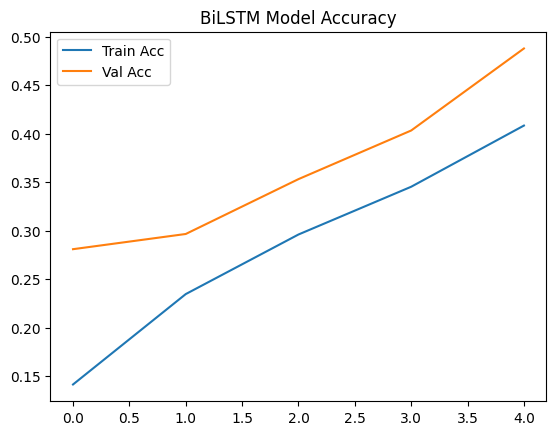

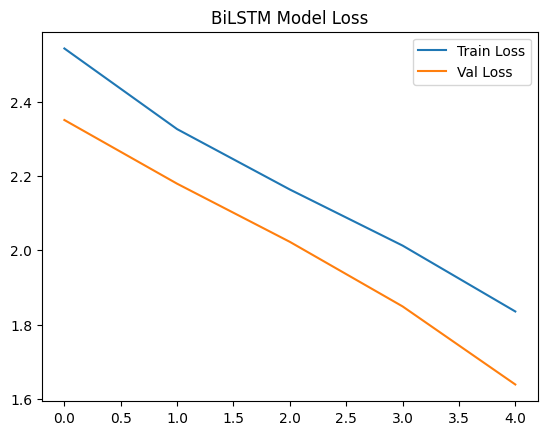

In [65]:
plot_training(history_bilstm, "BiLSTM Model")

In [64]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(y_true, y_pred, title="bilstm_model"):

    print(f"\n===== {title} Classification Report =====")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [63]:
def plot_training(history, title="bilstm_model"):

    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc(model, title="build_bilstm_only_model"):

    y_true_all = []
    y_score_all = []

    for i in range(0, len(test_seq), BATCH_SIZE):

        batch_seq = test_seq[i:i+BATCH_SIZE]
        batch_lbl = y_test[i:i+BATCH_SIZE]

        X_batch = []

        for seq in batch_seq:
            frames = []
            for path in seq:
                img = cv2.imread(path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                frames.append(img)

            X_batch.append(frames)

        X_batch = np.array(X_batch)

        preds = model.predict(X_batch, verbose=0)

        y_score_all.extend(preds)
        y_true_all.extend(batch_lbl)

    y_true_all = np.array(y_true_all)
    y_score_all = np.array(y_score_all)

    y_true_bin = label_binarize(y_true_all, classes=range(NUM_CLASSES))

    plt.figure()

    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"{title} ROC Curve")
    plt.legend()
    plt.show()

BiLSTM Test Accuracy: 0.3046
BiLSTM Final Training Accuracy: 0.4084
BiLSTM Final Validation Accuracy: 0.4879

===== BiLSTM Classification Report =====
              precision    recall  f1-score   support

           0       0.38      0.19      0.26       187
           1       0.00      0.00      0.00       187
           2       0.54      0.64      0.59       187
           3       0.42      0.24      0.30       187
           4       0.43      0.02      0.03       188
           5       0.79      0.86      0.82       187
           6       0.75      0.02      0.03       188
           7       0.25      0.01      0.01       187
           8       0.11      0.03      0.04       187
           9       0.13      0.49      0.21       187
          10       0.29      0.49      0.36       188
          11       0.41      0.51      0.46       187
          12       0.08      0.02      0.03       187
          13       0.23      0.80      0.36       187

    accuracy                         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


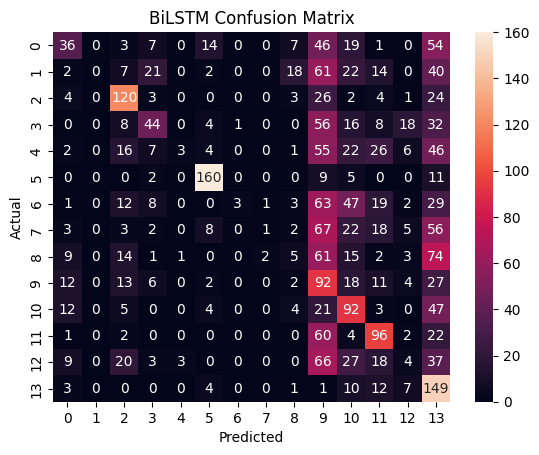

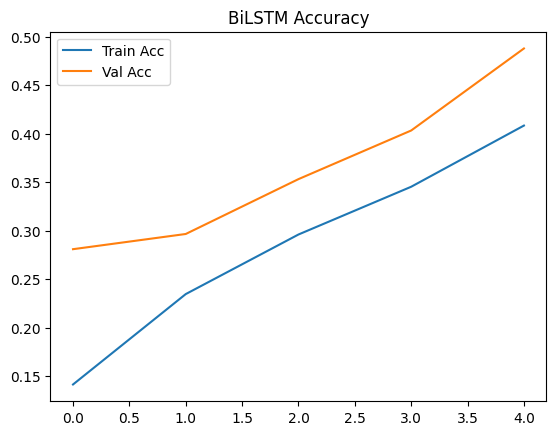

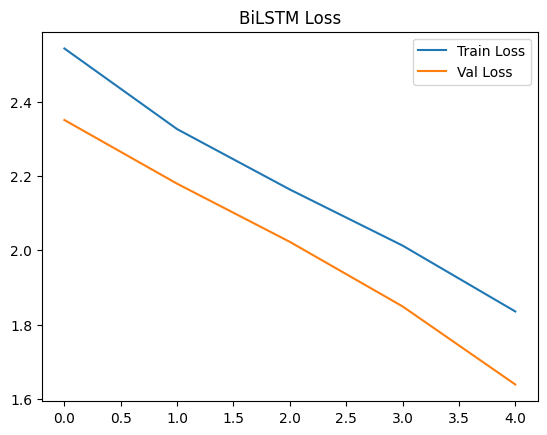

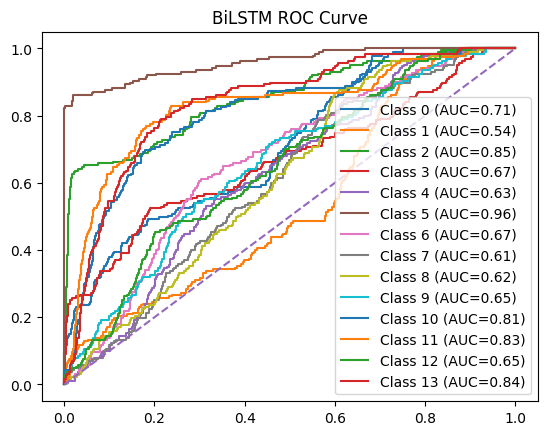

In [66]:
# ================= BiLSTM EVALUATION =================

# Generate predictions for the BiLSTM model on the test set
y_pred_classes_bilstm = []
y_true_labels_bilstm = []

# Re-initialize test_gen for predictions
test_gen_for_preds_bilstm = data_generator(test_seq, y_test, BATCH_SIZE)

num_test_samples = len(test_seq)
steps_for_prediction = (num_test_samples + BATCH_SIZE - 1) // BATCH_SIZE

for _ in range(steps_for_prediction):
    X_batch, y_batch = next(test_gen_for_preds_bilstm)
    preds = bilstm_model.predict(X_batch, verbose=0)
    y_pred_classes_bilstm.extend(np.argmax(preds, axis=1))
    y_true_labels_bilstm.extend(y_batch)

y_pred_classes_bilstm = np.array(y_pred_classes_bilstm)
y_true_labels_bilstm = np.array(y_true_labels_bilstm)

# Calculate and print test accuracy
bilstm_test_loss, bilstm_test_acc = bilstm_model.evaluate(test_gen, steps=len(test_seq)//BATCH_SIZE, verbose=0)
print(f"BiLSTM Test Accuracy: {bilstm_test_acc:.4f}")

# Print final training and validation accuracy from history
print(f"BiLSTM Final Training Accuracy: {history_bilstm.history['accuracy'][-1]:.4f}")
print(f"BiLSTM Final Validation Accuracy: {history_bilstm.history['val_accuracy'][-1]:.4f}")

# Evaluate and plot confusion matrix
evaluate_model(y_true_labels_bilstm, y_pred_classes_bilstm, "BiLSTM")

# Plot training and validation curves
plot_training(history_bilstm, "BiLSTM")

# Plot ROC curve
plot_roc(bilstm_model, "BiLSTM")